# Lab Assignment #02

This notebook covers the following:
- **Task 1:** Selective focus (Portrait mode effect) using masks and Gaussian Blur.
- **Task 2:** Pencil sketch effect using Color Dodge blending and Canny edge detection.


## Environment Setup

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to display images inline
def show_image(title, image, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

## Task 1: Portrait Mode Effect

Create a filter that mimics a portrait mode on a smartphone, where the subject is in focus but the background is artistically blurred.

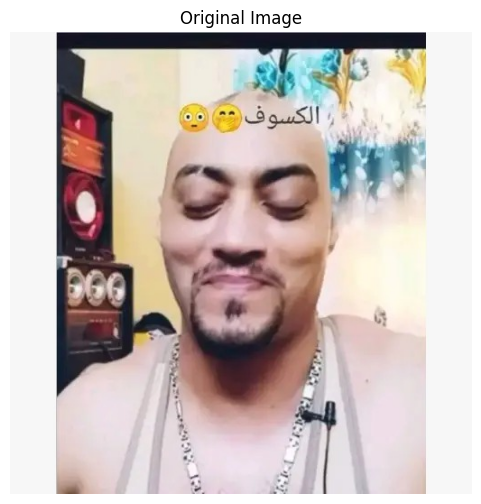

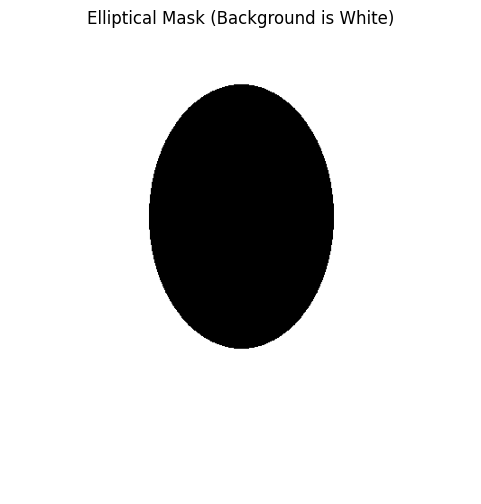

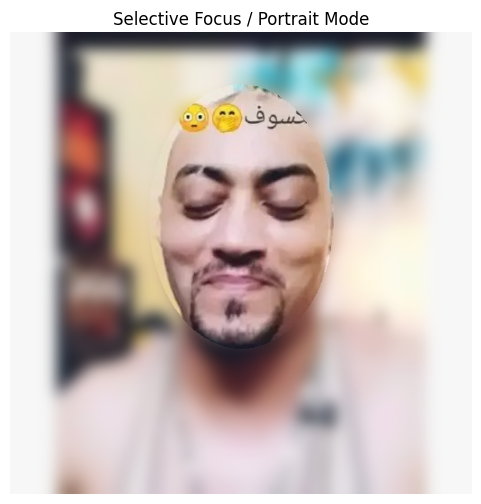

In [21]:
# 1. Load the original image
img_path_1 = 'person_with_background.jpg'
img1 = cv2.imread(img_path_1)

if img1 is not None:
    # Convert from BGR to RGB for Matplotlib
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    
    # 2. Create an elliptical mask
    # Using black (0) inside the ellipse and white (255) outside,
    # but we will invert it to extract the sharp subject later, since cv2.bitwise_and keeps pixels where mask > 0.
    mask = np.ones(img1.shape[:2], dtype=np.uint8) * 255
    
    center = (img1.shape[1] // 2, int(img1.shape[0] // 2.5))
    axes = (img1.shape[1] // 5, int(img1.shape[0] // 3.5))
    cv2.ellipse(mask, center, axes, 0, 0, 360, 0, -1) # Fill inside with black (0)
    
    # Mask for the subject (white inside, black outside)
    mask_subject = cv2.bitwise_not(mask)
    
    # 3. Create a heavily blurred version of the entire original image
    # The kernel size should be an odd number. Larger kernel = more blur.
    blurred_img = cv2.GaussianBlur(img1_rgb, (51, 51), 0)
    
    # 4. Use bitwise operations to combine the images
    # Extract the sharp subject using the inverted mask (white on subject)
    sharp_subject = cv2.bitwise_and(img1_rgb, img1_rgb, mask=mask_subject)
    
    # Extract the blurred background using the original mask (white on background)
    blurred_background = cv2.bitwise_and(blurred_img, blurred_img, mask=mask)
    
    # Combine both to get the final "selective focus" image
    selective_focus_img = cv2.bitwise_or(sharp_subject, blurred_background)
    
    # Display results
    show_image("Original Image", img1_rgb)
    show_image("Elliptical Mask (Background is White)", mask, cmap='gray')
    show_image("Selective Focus / Portrait Mode", selective_focus_img)

## Task 2: Pencil Sketch Effect

Convert a photograph into a pencil-sketch-like drawing using color dodging, and compare it with the Canny edge detector.

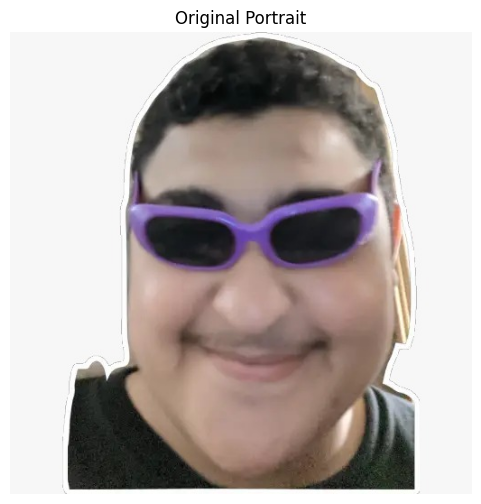

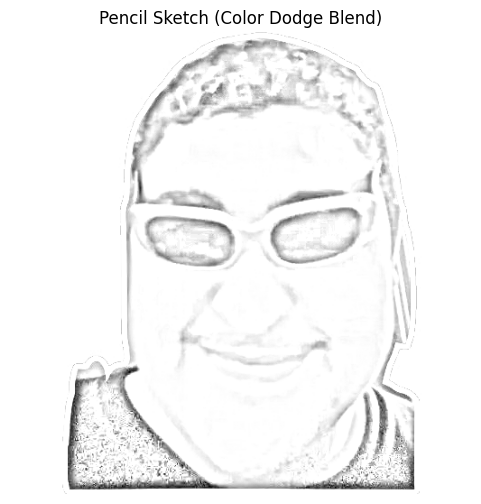

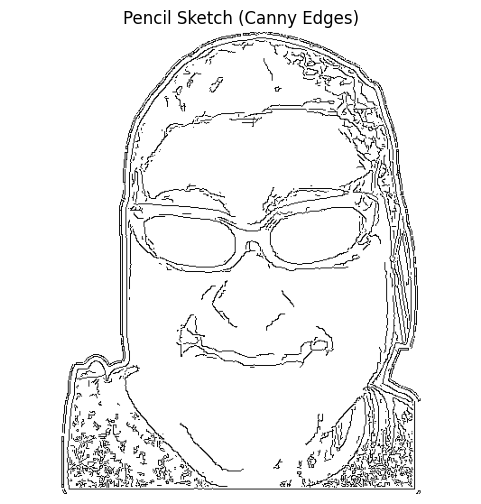

In [32]:
# 1. Load a color image
img_path_2 = 'portrait.jpg'
img2 = cv2.imread(img_path_2)

if img2 is not None:
    # Convert for display
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # 2. Invert and Blur
    # Convert to grayscale
    gray_img = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    # Invert the grayscale image
    inverted_img = cv2.bitwise_not(gray_img)
    
    # Apply a Gaussian blur
    # Adjust the kernel size to change the thickness/texture of the sketch lines
    blurred_inverted = cv2.GaussianBlur(inverted_img, (31, 31), 0)
    
    # 3. Create the Sketch using "Color Dodge" blend mode
    sketch_color_dodge = cv2.divide(gray_img, 255 - blurred_inverted, scale=256)
    
    # 4. Alternative Method: Canny Edge Detector
    edges = cv2.Canny(gray_img, 30, 75)
    
    # Invert edges so that the background is white and the lines are black (like a sketch)
    sketch_canny = cv2.bitwise_not(edges)
    
    # Display real comparison
    show_image("Original Portrait", img2_rgb)
    show_image("Pencil Sketch (Color Dodge Blend)", sketch_color_dodge, cmap='gray')
    show_image("Pencil Sketch (Canny Edges)", sketch_canny, cmap='gray')